In [81]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


r_source = 10 #diameter of the light disk
N = 1000 #number of particles
k_0 = 1 #standard length of k
a = 0.1 #size of features in the plots

#angles of the filters
angle1 = 2*np.pi*float(input("Enter angle 1: "))/360
angle2 = 2*np.pi*float(input("Enter angle 2: "))/360

In [82]:
class ParticleClass:
    def __init__(self, r, k):
        #lichtdeeltje met positie r en golfvector k
        self.r = r
        self.k = k
    
    def filter_k(self, theta):
        kx, ky = self.k
        #lengte k
        k_abs = np.sqrt(kx**2+ky**2)
        #hoek phi van de vector k
        phi = np.arctan2(ky, kx)
        #r wordt gefilterd zodat de component parallel aan de filter doorgaat
        self.k[0] = -np.sin(theta)*k_abs*np.cos(phi-theta)
        self.k[1] = np.cos(theta)*k_abs*np.cos(phi-theta)

In [83]:
def create_particles(particles):
    #leegmaken en opnieuw maken
    particles.clear()
    for _ in range(N):
        #golfvector lichtdeeltje:
        kx = np.random.uniform(-k_0, k_0)
        ky = np.random.choice([-1, 1]) * np.sqrt(k_0**2 - kx**2)
        #locatie lichtdeeltje:
        theta = np.random.uniform(0, 2*np.pi)
        radius = r_source * np.sqrt(np.random.uniform(0, 1))
        rx = radius * np.cos(theta)
        ry = radius * np.sin(theta)

        particles.append(ParticleClass(k=[kx, ky], r=[rx, ry]))

In [84]:
def filter(particles, theta):
    for p in particles:
        p.filter_k(theta)

def average_k_length(particles):
    lengths = [np.linalg.norm(p.k) for p in particles]
    return np.mean(lengths)



def plot():
    plt.figure()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.gca().set_aspect('equal')
    plt.xlim(-1.1*r_source, 1.1*r_source)
    plt.ylim(-1.1*r_source, 1.1*r_source)

    for p in particles:
        plt.plot(p.r[0], p.r[1], 'k.', ms=25*a)
        plt.arrow(p.r[0], p.r[1], p.k[0], p.k[1], width=.2*a,
              head_width=a, head_length=a, color='red')
    plt.show()

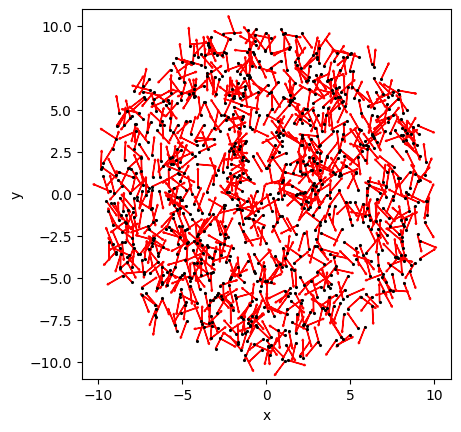

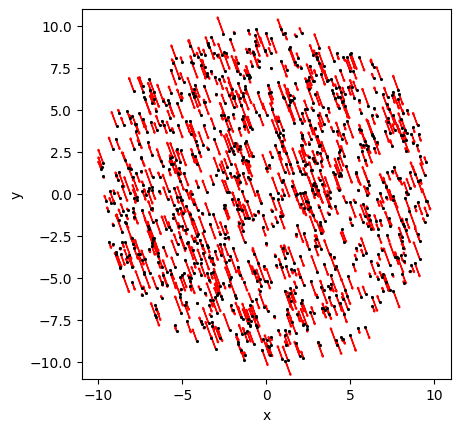

the percentage intensity after the first pair of glasses is: 28.05 %


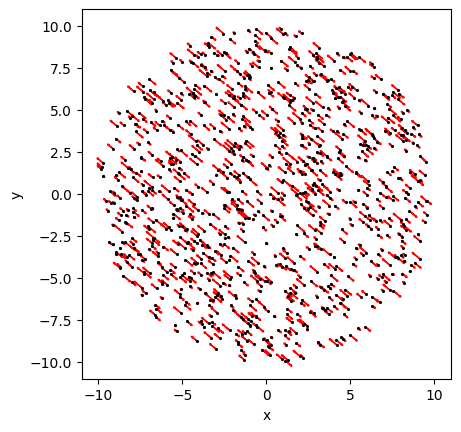

the percentage intensity after the second pair of glasses is: 7.01 %
the percentage intensity between the first and second pair of glasses is: 25.00 %
theoretisch gezien:25.0 %
verschil vergeleken met theorie: 0.0 %


In [85]:
particles = []
create_particles(particles)

#initial
avg_before = average_k_length(particles)
plot()

#filter 1
filter(particles, angle1)
avg_after_1 = average_k_length(particles)
plot()

print(f"the percentage intensity after the first pair of glasses is: {100*(avg_after_1**2/avg_before**2):.2f} %")

#filter 2
filter(particles, angle2)
avg_after_2 = average_k_length(particles)
plot()

print(f"the percentage intensity after the second pair of glasses is: {100*(avg_after_2**2/avg_before**2):.2f} %")
print(f"the percentage intensity between the first and second pair of glasses is: {100*(avg_after_2**2/avg_after_1**2):.2f} %")
print(f"theoretisch gezien:{100*np.sin(angle2-angle1)**2} %")
print(f"verschil vergeleken met theorie: {100*(np.sin(angle2-angle1)**2-(avg_after_2**2/avg_after_1**2))/np.sin(angle2-angle1)**2} %")